## Ordinary Least Squares Regression Model

### OLS Model Summary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
data = pd.read_excel("/content/rev_ds.xlsx")
data = data.drop('No', axis=1)
new_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1']
data.columns = new_cols
X = data[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
y = data['y1']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     y1   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     94.60
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.83e-74
Time:                        21:09:47   Log-Likelihood:                -1487.0
No. Observations:                 414   AIC:                             2988.
Df Residuals:                     407   BIC:                             3016.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.444e+04   6775.386     -2.132      0.0

### OLS Residuals

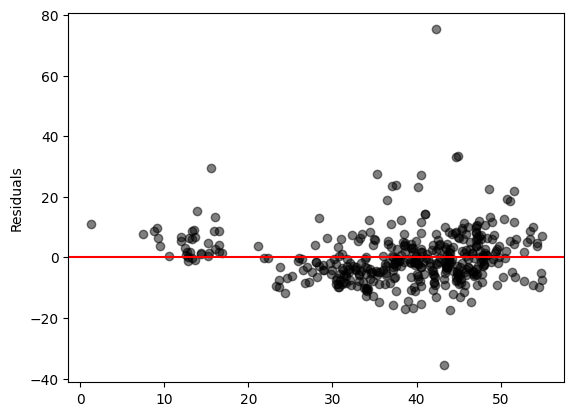

In [ ]:
fitted = model.fittedvalues
resid = model.resid
plt.scatter(fitted, resid, alpha=0.5, color='black')
plt.axhline(0, color='red')
plt.ylabel("Residuals")
plt.show()

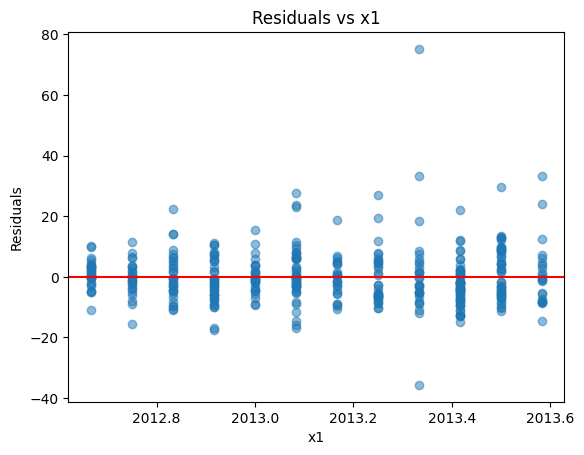

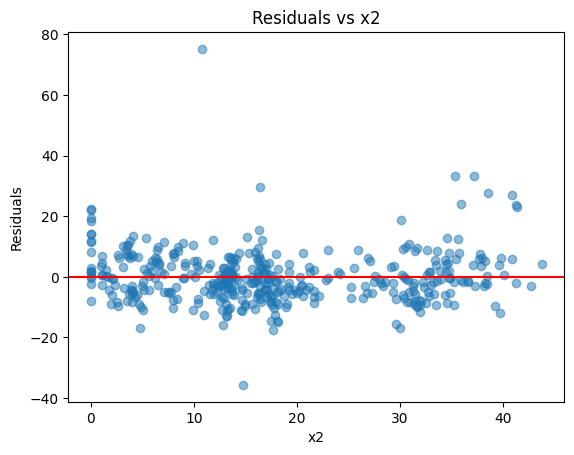

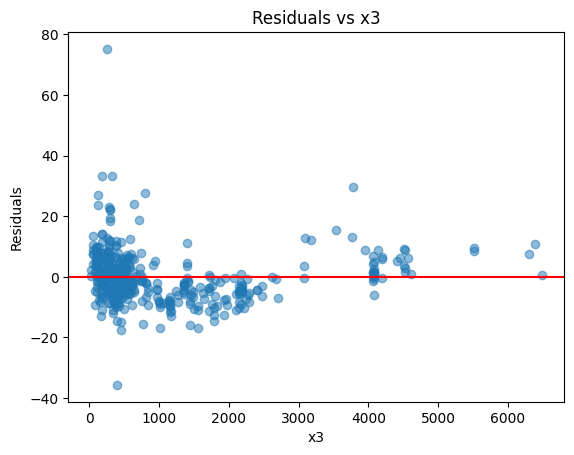

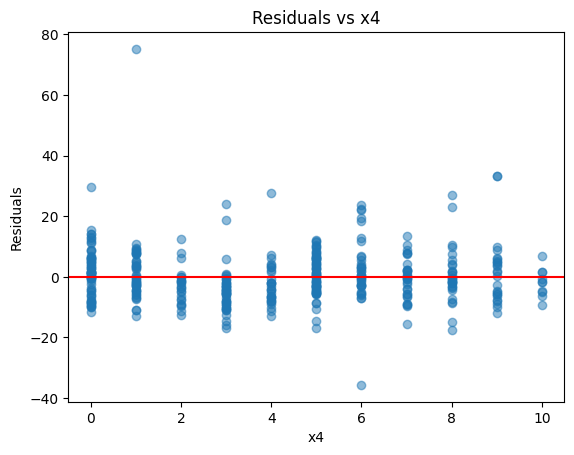

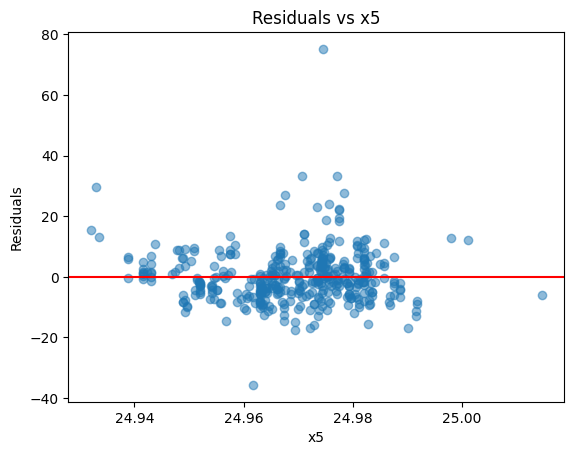

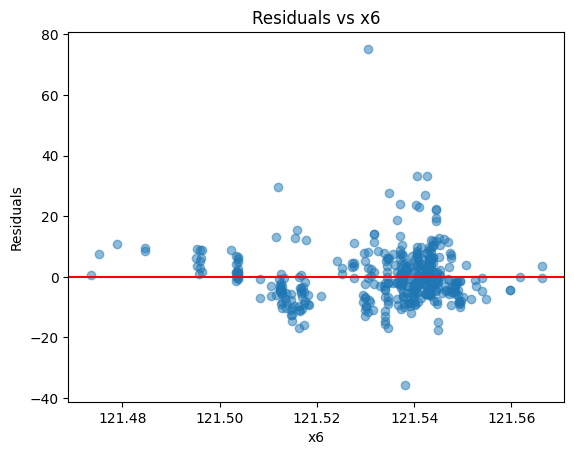

In [ ]:
for col in ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']:
    plt.scatter(data[col], resid, alpha=0.5)
    plt.axhline(0, color='red')
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {col}")
    plt.show()

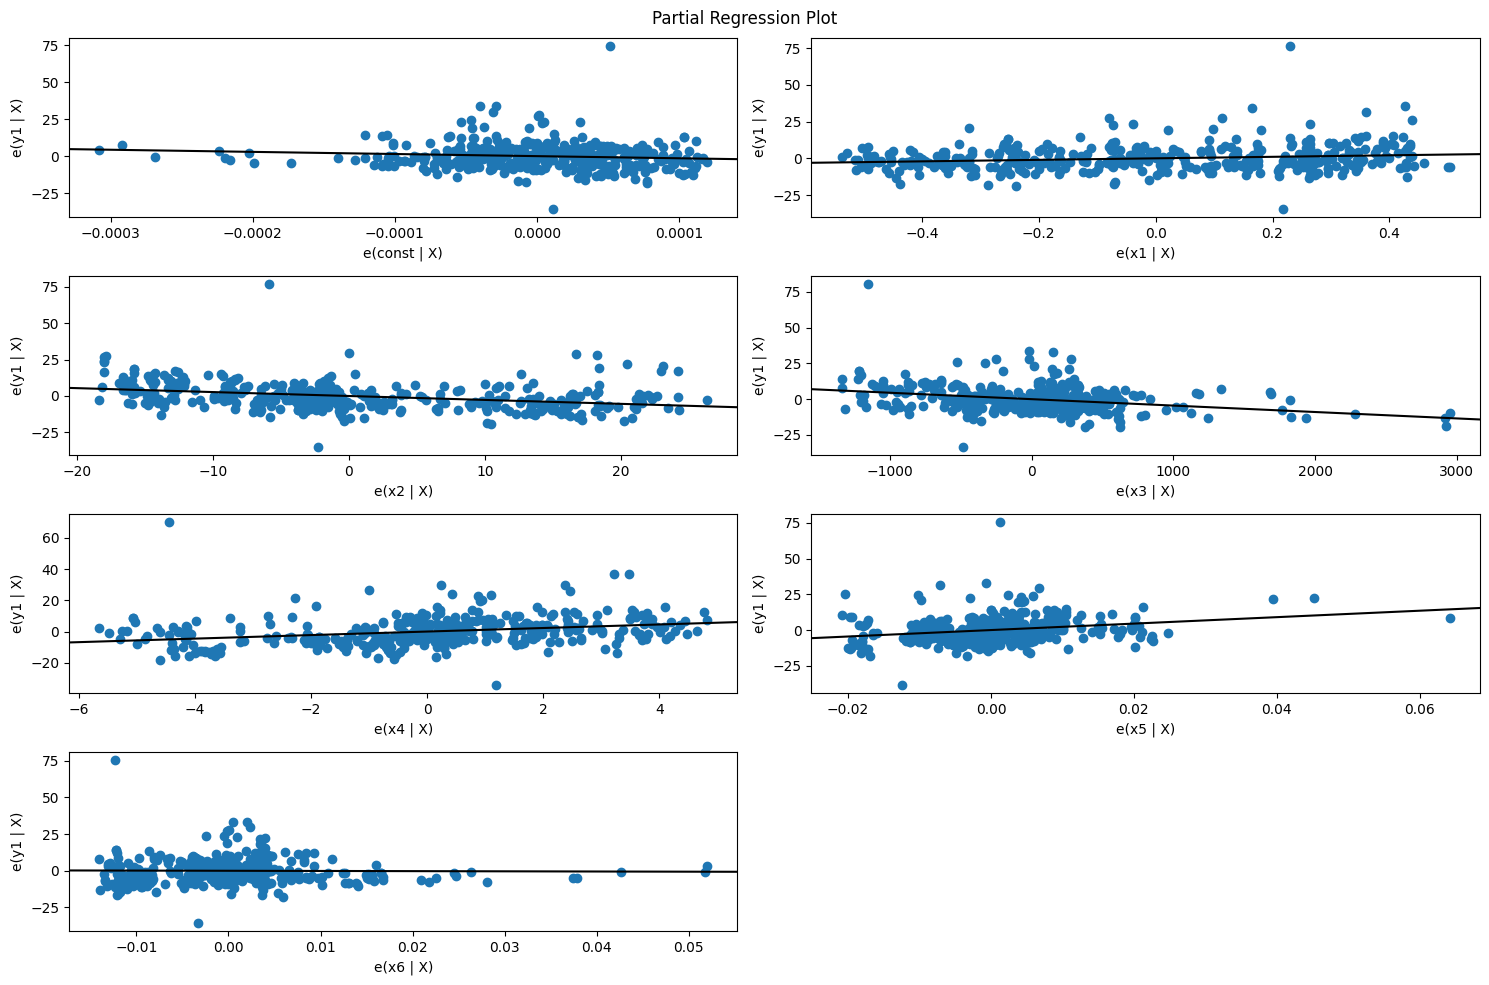

In [ ]:
from statsmodels.graphics.regressionplots import plot_partregress_grid
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 10))
fig = plot_partregress_grid(model, fig=fig)
fig.tight_layout()
plt.show()

## Refined Ordinary Least Squares Regression Model

### Refined OLS Model Summary

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
data['x3_log'] = np.log(data['x3'] + 1)
data['x2_sq'] = data['x2']**2
coords = data[['x5', 'x6']]
coords_scaled = StandardScaler().fit_transform(coords)
pca = PCA(n_components=1)
data['spatial_pc1'] = pca.fit_transform(coords_scaled)
X = data[['x1', 'x2', 'x2_sq', 'x3_log', 'x4', 'spatial_pc1']]
X = sm.add_constant(X)
y = data['y1']
model_refined = sm.OLS(y, X).fit()

print(model_refined.summary())

                            OLS Regression Results                            
Dep. Variable:                     y1   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     129.6
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           3.37e-91
Time:                        21:11:38   Log-Likelihood:                -1446.5
No. Observations:                 414   AIC:                             2907.
Df Residuals:                     407   BIC:                             2935.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.379e+04   2858.188     -4.825      

### Refined OLS Residuals

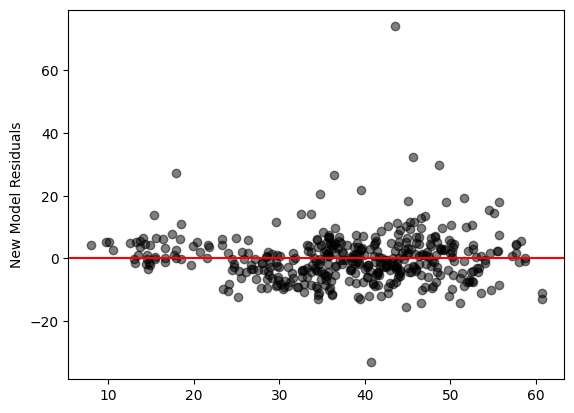

In [ ]:
fitted_refined = model_refined.fittedvalues
resid_refined = model_refined.resid
plt.scatter(fitted_refined, resid_refined, alpha=0.5, color='black')
plt.axhline(0, color='red')
plt.ylabel("New Model Residuals")
plt.show()

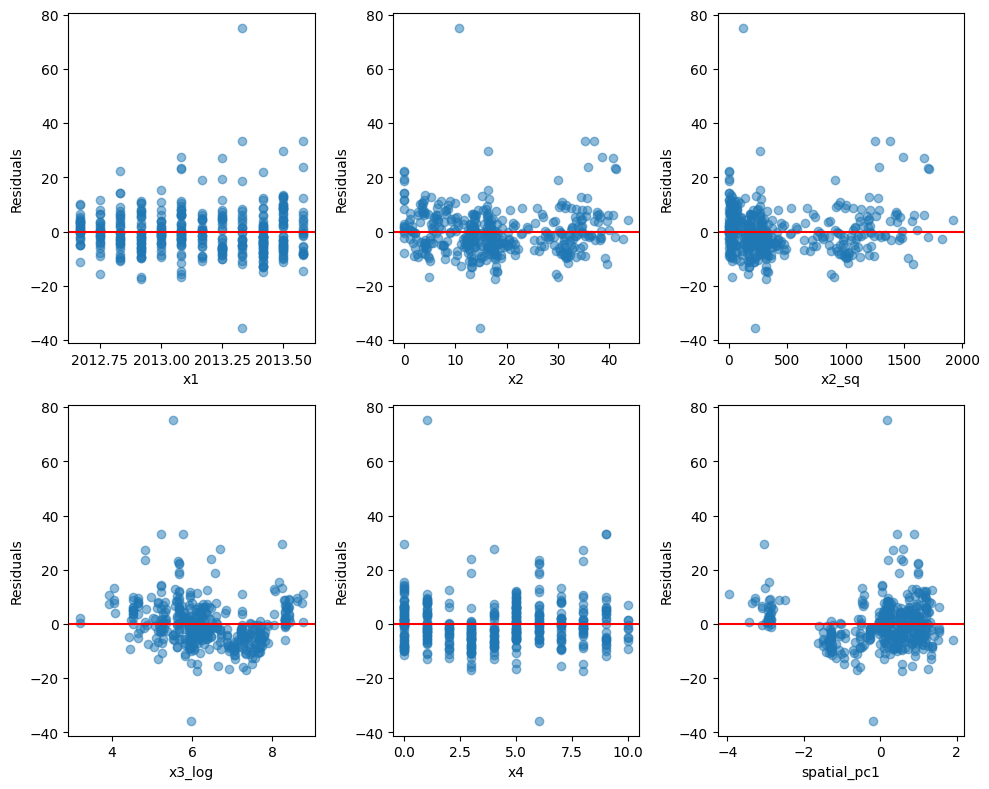

In [ ]:
# refined model residuals vs predictors
num = 5
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
ax_flat = ax.flatten()
for i, col in enumerate(['x1', 'x2', 'x2_sq', 'x3_log', 'x4', 'spatial_pc1']):
    current_ax = ax_flat[i]
    current_ax.scatter(data[col], resid, alpha=0.5)
    current_ax.axhline(0, color='red')
    current_ax.set_xlabel(col)
    current_ax.set_ylabel("Residuals")
plt.tight_layout()
plt.show()

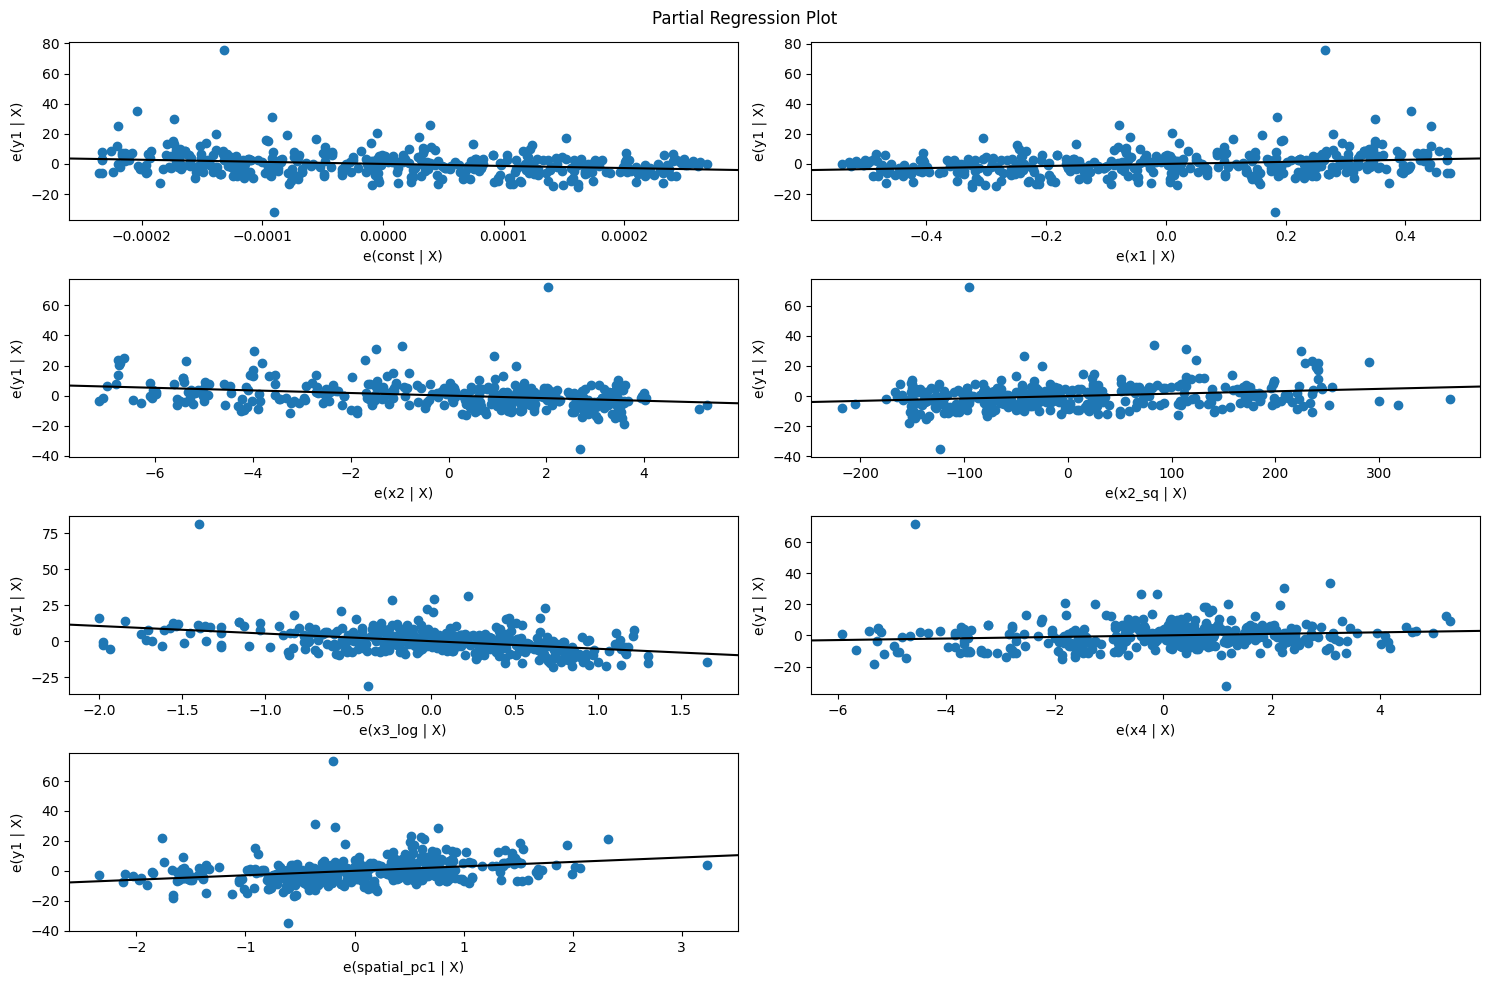

In [ ]:
# refined model partial residual plots
fig = plt.figure(figsize=(15, 10))
fig = plot_partregress_grid(model_refined, fig=fig)
fig.tight_layout()
plt.show()

## Bootstrapping

### Residuals Bootstrap

In [ ]:
residuals = model_refined.resid
pred_y = model_refined.fittedvalues
Y_boot_full = []
B = 5000
n, p = X.shape
boot_betas = np.zeros((B, p))
for i in range(B):
    rand_res = np.random.choice(residuals, size=n, replace=True)
    y_boot_val = y + rand_res
    boot_model = sm.OLS(y_boot_val, X).fit()
    boot_betas[i, :] = boot_model.params
boot_se = boot_betas.std(axis=0, ddof=1)
names = ["const", "x1", "x2", "x2_sq", "x3_log", "x4", "spatial_pc1"]
for name, se in zip(names, boot_se):
    print(f"{name:12s} bootstrap SE = {se:.6f}")
ci_lower = np.percentile(boot_betas, 2.5, axis=0)
ci_upper = np.percentile(boot_betas, 97.5, axis=0)
print("\n95% bootstrap percentile CIs:")
for name, lo, hi in zip(names, ci_lower, ci_upper):
    print(f"{name:12s} [{lo:.6f}, {hi:.6f}]")

const        bootstrap SE = 2848.354860
x1           bootstrap SE = 1.415174
x2           bootstrap SE = 0.139395
x2_sq        bootstrap SE = 0.003362
x3_log       bootstrap SE = 0.583135
x4           bootstrap SE = 0.186607
spatial_pc1  bootstrap SE = 0.445335

95% bootstrap percentile CIs:
const        [-19281.120047, -8308.368515]
x1           [4.162506, 9.616271]
x2           [-1.136669, -0.595628]
x2_sq        [0.009441, 0.022780]
x3_log       [-6.400526, -4.151153]
x4           [0.129108, 0.864183]
spatial_pc1  [2.125126, 3.835593]


### Case Bootstrap

In [ ]:
B = 5000
n, p = X.shape # Use the existing X (from the refined model)
boot_betas_2 = np.zeros((B, p))
for i in range(B):
    index = np.random.choice(n, size=n, replace=True)
    X_boot = X.iloc[index, :]
    y_boot = y.iloc[index]
    boot_model = sm.OLS(y_boot, X_boot).fit()
    boot_betas_2[i, :] = boot_model.params
boot_se = boot_betas_2.std(axis=0, ddof=1)
names = ["const", "x1", "x2", "x2_sq", "x3_log", "x4", "spatial_pc1"]
print("Case-bootstrap SEs:")
for name, se in zip(names, boot_se):
    print(f"{name:12s} bootstrap SE = {se:.6f}")
ci_lower = np.percentile(boot_betas_2, 2.5, axis=0) # Use boot_betas_2
ci_upper = np.percentile(boot_betas_2, 97.5, axis=0) # Use boot_betas_2
print("\n95% bootstrap percentile CIs:")
for name, lo, hi in zip(names, ci_lower, ci_upper):
    print(f"{name:12s} [{lo:.6f}, {hi:.6f}]")

Case-bootstrap SEs:
const        bootstrap SE = 2733.676498
x1           bootstrap SE = 1.358912
x2           bootstrap SE = 0.150197
x2_sq        bootstrap SE = 0.003826
x3_log       bootstrap SE = 0.771971
x4           bootstrap SE = 0.252981
spatial_pc1  bootstrap SE = 0.404507

95% bootstrap percentile CIs:
const        [-19151.137634, -8380.741783]
x1           [4.195741, 9.554836]
x2           [-1.156238, -0.558760]
x2_sq        [0.008472, 0.023569]
x3_log       [-6.923602, -3.899806]
x4           [-0.049669, 0.946729]
spatial_pc1  [2.211706, 3.788943]


## Logistic Regression On Binarized Outcome Variable

### Logistic Regression Model Summary

In [ ]:
median_cut = data["y1"].median()
data["y_bin"] = (data["y1"] >= median_cut).astype(int)

X_logit = data[["x1", "x2", "x2_sq", "x3_log", "x4", "spatial_pc1"]]
X_logit = sm.add_constant(X_logit)
y_logit = data["y_bin"]

logit_model = sm.Logit(y_logit, X_logit).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.351799
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                  414
Model:                          Logit   Df Residuals:                      407
Method:                           MLE   Df Model:                            6
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.4925
Time:                        19:28:38   Log-Likelihood:                -145.64
converged:                       True   LL-Null:                       -286.96
Covariance Type:            nonrobust   LLR p-value:                 4.284e-58
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2657.0938   1114.779     -2.384      0.017   -4842.021    -472.167
x1              1.3251   

### LASSO Regression

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['x1', 'x2', 'x2_sq', 'x3_log', 'x4', 'spatial_pc1']])

lasso = LogisticRegressionCV(
    penalty="l1",
    solver="liblinear",
    cv=5,
    scoring="accuracy",
    max_iter=1000
)
lasso.fit(X_scaled, y_logit)

selected_features = np.array(["x1", "x2", "x2_sq", "x3_log", "x4", "spatial_pc1"])[lasso.coef_[0] != 0]
print("Selected features by Lasso:", selected_features)

Selected features by Lasso: ['x1' 'x2' 'x3_log' 'x4' 'spatial_pc1']


### Logistic Regression Bootstrapping

In [ ]:
B = 1000
coeffs = []
for _i in range(B):
    sample = data.sample(len(data), replace=True)
    # redo transforms for the sample
    sample["x2_sq"] = sample["x2"]**2
    sample["x3_log"] = np.log(sample["x3"] + 1)

    # Re-apply StandardScaler and PCA for spatial_pc1 on resampled data
    # Create a new StandardScaler and PCA for each bootstrap sample's coordinates
    coords_sample = sample[['x5', 'x6']]
    coords_scaler_boot = StandardScaler()
    coords_scaled_sample = coords_scaler_boot.fit_transform(coords_sample)
    pca_boot = PCA(n_components=1)
    sample["spatial_pc1"] = pca_boot.fit_transform(coords_scaled_sample)

    Xb = sample[['x1', 'x2', 'x2_sq', 'x3_log', 'x4', 'spatial_pc1']]
    yb = (sample["y1"] >= median_cut).astype(int)

    # Use the global scaler (fitted on original X for Lasso) to transform Xb
    Xb_scaled = scaler.transform(Xb)
    lasso.fit(Xb_scaled, yb)

    sel = np.array(["x1", "x2", "x2_sq", "x3_log", "x4", "spatial_pc1"])[lasso.coef_[0] != 0]
    if len(sel) > 0:
        X_sel = sm.add_constant(sample[sel])
        model = sm.Logit(yb, X_sel).fit(disp=0)
        coeffs.append(model.params)

boot_df = pd.DataFrame(coeffs)
boot_se = boot_df.std()
print(boot_se)

const          1549.911839
x2                0.068496
x3_log            0.303302
x4                0.068486
spatial_pc1       0.324777
x1                0.522273
x2_sq             0.001745
dtype: float64
